In [1]:
# Importing the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import GlorotUniform, HeNormal
import shap

# load the dataset
dataset = pd.read_excel('BBDM Project for 2nd research article.xlsx')

# Columns to exclude
columns_to_exclude = ['Chainage', 'Formation','RMC']
# Prepare the features and target variable
X = dataset.drop(['PRnet'] + columns_to_exclude, axis=1)
y = dataset['PRnet']

# Label encoding for categorical columns
label_encoder = LabelEncoder()
for col in ['Lithology', 'Weathering', 'Rock Strength']:
    X[col] = label_encoder.fit_transform(X[col])

# Save the feature names
feature_names = X.columns

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the optimal model based on the best hyperparameters found
def create_optimal_model():
    model = Sequential([
        Dense(units=352, activation='relu', kernel_initializer='glorot_uniform', input_shape=(X_train.shape[1],)),
        Dense(units=1, activation='relu', kernel_initializer='he_normal')
    ])
    adam_optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=adam_optimizer,
                  loss='mean_absolute_error',  # Use Mean Absolute Error as the loss function
                  metrics=['mean_absolute_error', 'mean_squared_error'])
    return model

# Create and train the model
optimal_model = create_optimal_model()
optimal_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test), verbose=2)

# Evaluate the model
loss, mse_eval = optimal_model.evaluate(X_test_scaled, y_test)
print(f"Test MSE: {mse_eval}")

# Use the model for prediction
predictions = optimal_model.predict(X_test_scaled).flatten()

Epoch 1/50
216/216 - 1s - loss: 3716.7192 - mean_squared_error: 3716.7192 - val_loss: 2439.7510 - val_mean_squared_error: 2439.7510 - 587ms/epoch - 3ms/step
Epoch 2/50
216/216 - 0s - loss: 1299.9817 - mean_squared_error: 1299.9817 - val_loss: 423.6460 - val_mean_squared_error: 423.6460 - 206ms/epoch - 954us/step
Epoch 3/50
216/216 - 0s - loss: 203.0190 - mean_squared_error: 203.0190 - val_loss: 89.8900 - val_mean_squared_error: 89.8900 - 205ms/epoch - 948us/step
Epoch 4/50
216/216 - 0s - loss: 59.4155 - mean_squared_error: 59.4155 - val_loss: 40.0476 - val_mean_squared_error: 40.0476 - 200ms/epoch - 924us/step
Epoch 5/50
216/216 - 0s - loss: 33.9829 - mean_squared_error: 33.9829 - val_loss: 26.4061 - val_mean_squared_error: 26.4061 - 203ms/epoch - 938us/step
Epoch 6/50
216/216 - 0s - loss: 26.5884 - mean_squared_error: 26.5884 - val_loss: 22.5604 - val_mean_squared_error: 22.5604 - 210ms/epoch - 970us/step
Epoch 7/50
216/216 - 0s - loss: 23.8573 - mean_squared_error: 23.8573 - val_loss

In [2]:
import shap
import matplotlib
import matplotlib.pyplot as plt

# Set the default font to Arial for all text elements
matplotlib.rcParams['font.family'] = 'Arial'
# Create an explainer object
explainer = shap.Explainer(optimal_model, X_train_scaled)
# Calculate SHAP values
shap_values = explainer(X_test_scaled)

# Calculate the mean absolute SHAP value for each feature
mean_shap_values = np.mean(np.abs(shap_values.values), axis=0)

# Combine features with their average SHAP values
feature_shap_pairs = list(zip(feature_names, mean_shap_values))

# Sort features by their average SHAP values
feature_shap_pairs.sort(key=lambda x: x[1], reverse=True)
features, avg_shap_values = zip(*feature_shap_pairs)

# Create a bar plot for the average SHAP values
plt.figure(figsize=(8, 6), dpi=1200)
bars = plt.barh(features, avg_shap_values, color='skyblue')

# Add value annotations to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
             va='center', ha='left', color='black', fontsize=16)
# Change tick font size and color
plt.xticks(fontsize=16, color='black')  # Set x-tick font size and color
plt.yticks(fontsize=16, color='black')  # Set y-tick font size and color

plt.xlabel('mean (|SHAP value|)', fontsize=16, color='black')
#plt.title('Average SHAP Values for Each Feature')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest values on top

# Display the plot
plt.title('a)', x=-0.15,y=1, fontsize=16)
plt.tight_layout()

# Save the figure
plt.savefig('1.Feature_importance_2nd_Journal.png', bbox_inches='tight', dpi=1200)
plt.show()

ExactExplainer explainer: 1724it [00:26, 44.97it/s]                          


ExactExplainer explainer: 1724it [00:28, 35.70it/s]                          


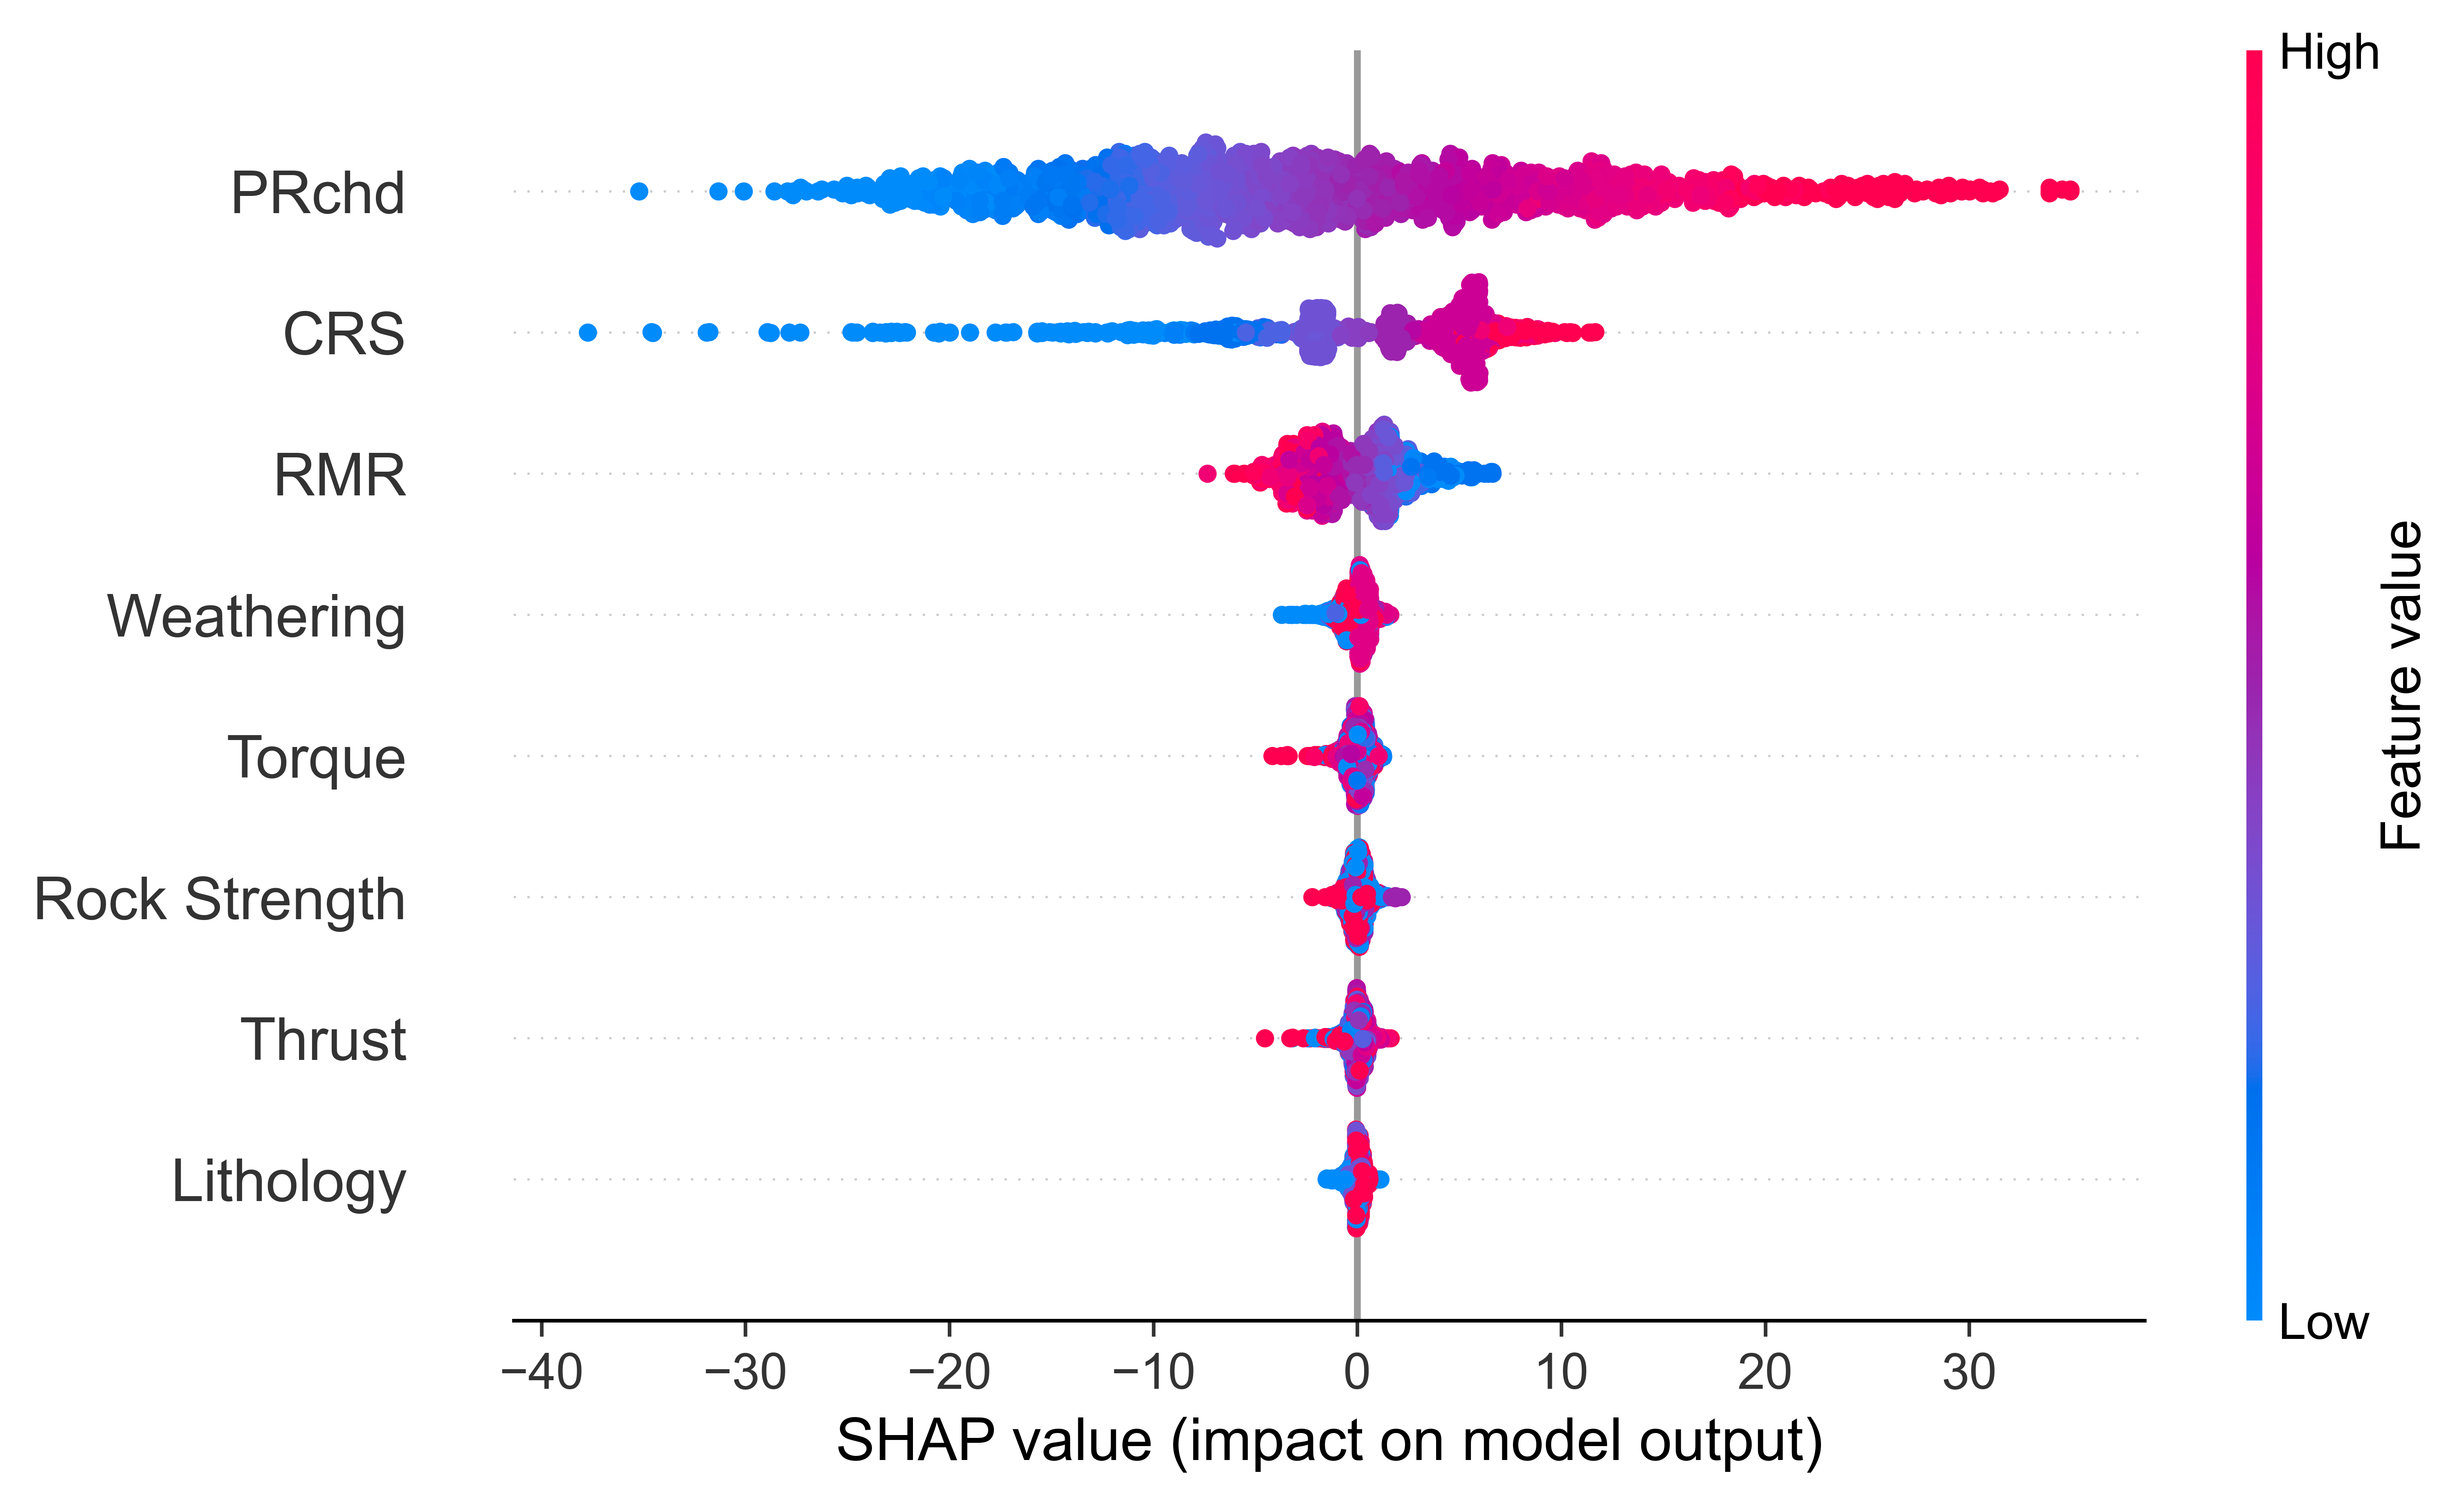

In [3]:
# SHAP analysis
# Load the SHAP library
import shap
import matplotlib
import matplotlib.pyplot as plt

# Set the default font to Arial for all text elements
matplotlib.rcParams['font.family'] = 'Arial'
plt.figure(figsize=(8, 6), dpi=800)
# Create an explainer object
explainer = shap.Explainer(optimal_model, X_train_scaled)

# Calculate SHAP values
shap_values = explainer(X_test_scaled)

# Create a SHAP summary plot and save it
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)

# Save the plot
plt.savefig("1.shap_summary_plot.png", dpi=800, bbox_inches='tight')

# Show the plot (optional)
plt.show()

## for Water fall

ExactExplainer explainer: 1724it [00:31, 36.58it/s]                          


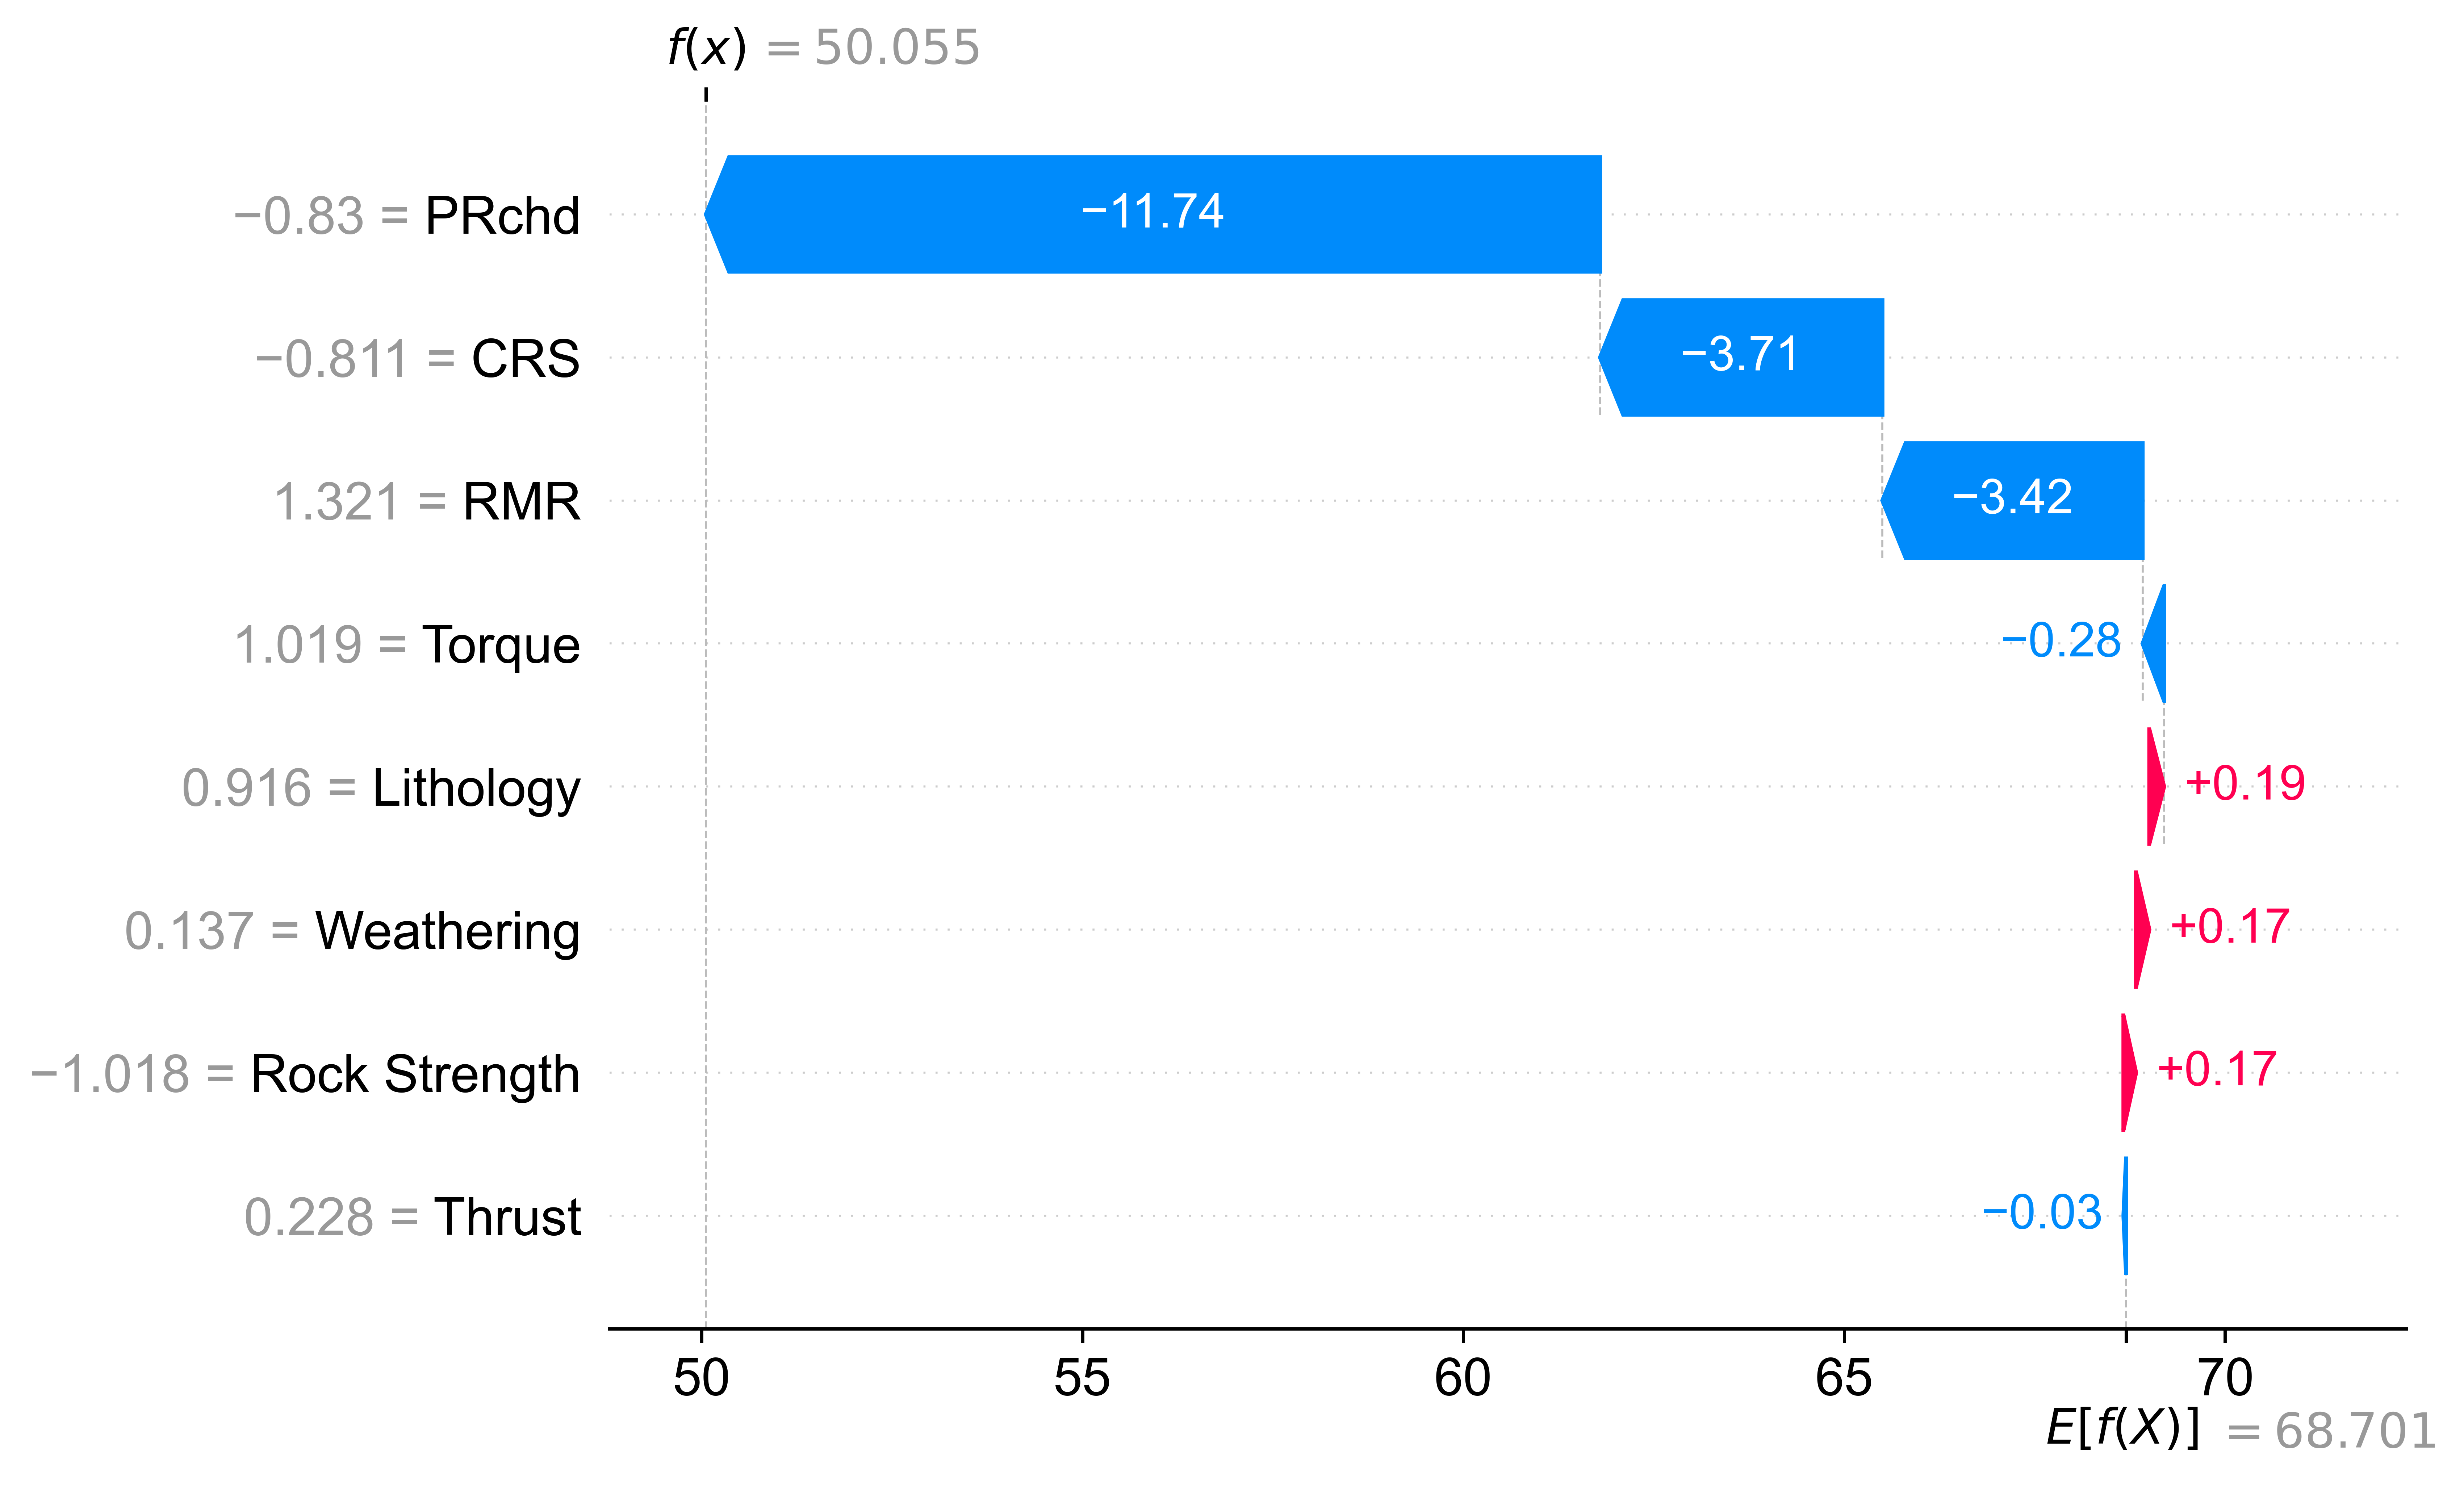

In [5]:
# SHAP analysis
# Load the SHAP library
import shap
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6), dpi=800)
# Set the default font to Arial for all text elements
matplotlib.rcParams['font.family'] = 'Arial'

# Create an explainer object with feature names
explainer = shap.Explainer(optimal_model, X_train_scaled, feature_names=feature_names)

# Calculate SHAP values
shap_values = explainer(X_test_scaled)

# Plot waterfall SHAP plot for the first instance in the test set
shap.plots.waterfall(shap_values[0], max_display=20) # shap_values[0] means sample index 
plt.show()

ExactExplainer explainer: 1724it [00:56, 21.64it/s]                          


<Figure size 9600x4800 with 0 Axes>

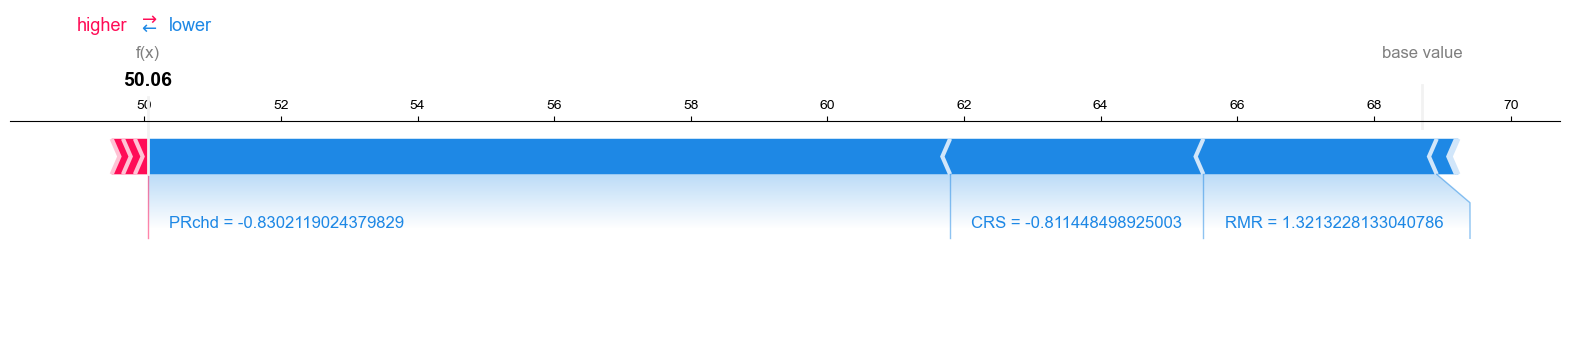

In [6]:
# Load the SHAP library
import shap
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6), dpi=800)
# Set the default font to Arial for all text elements
matplotlib.rcParams['font.family'] = 'Arial'

# Create an explainer object with feature names
explainer = shap.Explainer(optimal_model, X_train_scaled, feature_names=feature_names)

# Calculate SHAP values
shap_values = explainer(X_test_scaled)

# Plot force SHAP plot for the first instance in the test set
shap.plots.force(shap_values[0],matplotlib=True) # shap_values[0] means sample index 
plt.show()


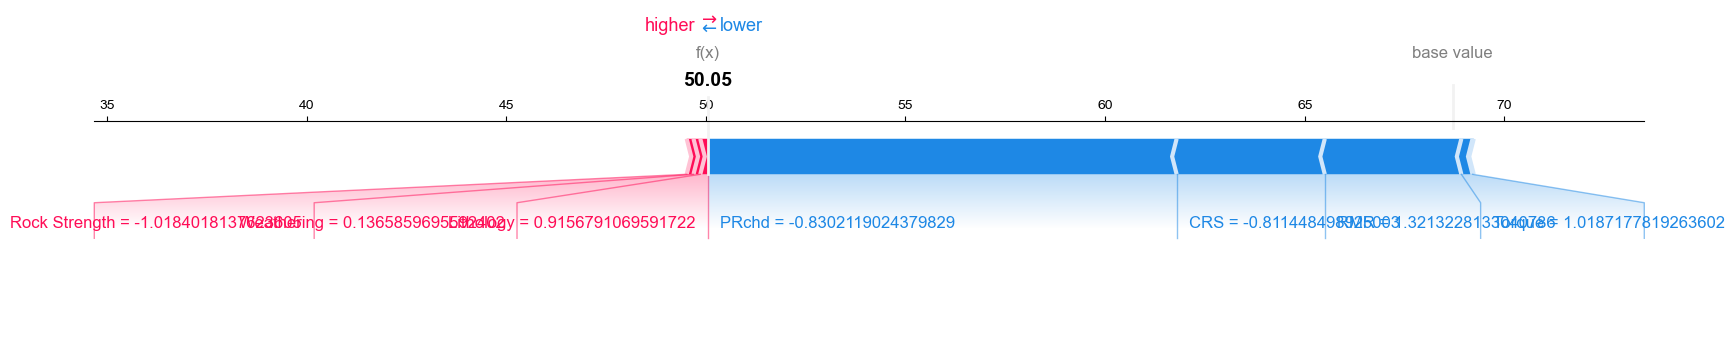

In [7]:
# Round SHAP values to two decimal points
shap_values.values = np.round(shap_values.values, 2)
# Plot force SHAP plot for the first instance in the test set
shap.plots.force(shap_values[0], matplotlib=True,contribution_threshold=0.01) # shap_values[0] means sample index 
plt.show()

## TBM stuck section

ExactExplainer explainer: 8615it [06:03, 22.65it/s]                           


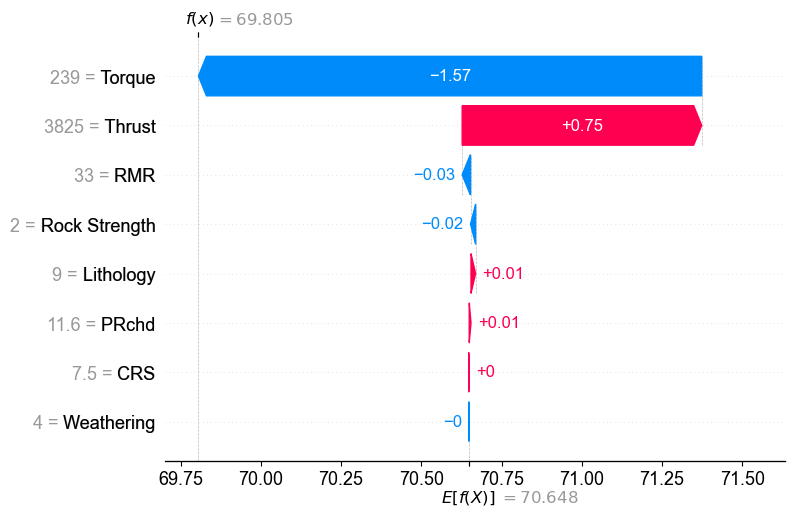

In [12]:
# Load the SHAP library
import shap
import matplotlib.pyplot as plt
import matplotlib

# Set the default font to Arial for all text elements
matplotlib.rcParams['font.family'] = 'Arial'

# Combine training and testing data back into the full dataset
X_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
X_full_array = X_full.values

# Create an explainer object with feature names using the full dataset
explainer = shap.Explainer(optimal_model, X_full_array, feature_names=feature_names)
shap_values = explainer(X_full_array)

# Find the specific instance's index in the full dataset
instance_index = 6027  # Index of the instance you want to visualize

# Plot waterfall SHAP plot for the specific instance
shap.plots.waterfall(shap_values[instance_index], max_display=20)
plt.show()